# Aufgabe 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.filters import gaussian, laplace, sobel
from skimage.util import img_as_float, random_noise

## 1.1

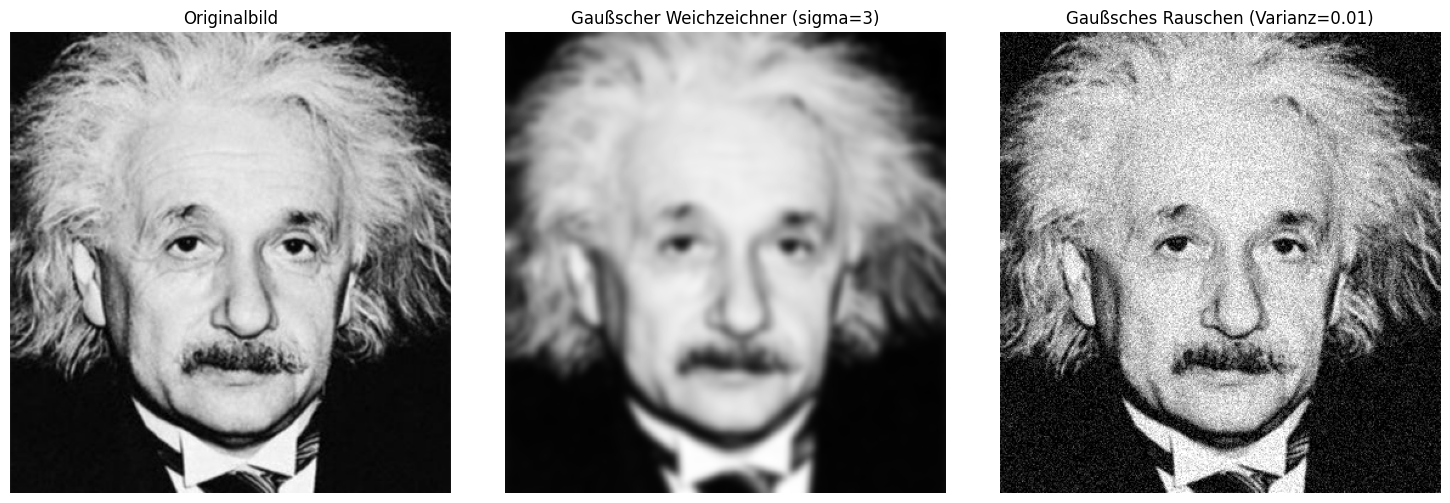

In [4]:
# Einstein Bild laden
img_original = imread("einstein.png")

# bild im bereich [0, 1] bringen
img = img_as_float(img_original)

# Gaußscher Weichzeichner mit sigma=3
img_gaussian = gaussian(img, sigma=3)

# Gaußsches Rauschen mit Varianz 0.01
img_noisy = random_noise(img, mode='gaussian', var=0.01)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Originalbild")
axes[0].axis('off')

axes[1].imshow(img_gaussian, cmap='gray')
axes[1].set_title("Gaußscher Weichzeichner (sigma=3)")
axes[1].axis('off')

axes[2].imshow(img_noisy, cmap='gray')
axes[2].set_title("Gaußsches Rauschen (Varianz=0.01)")
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 1.2

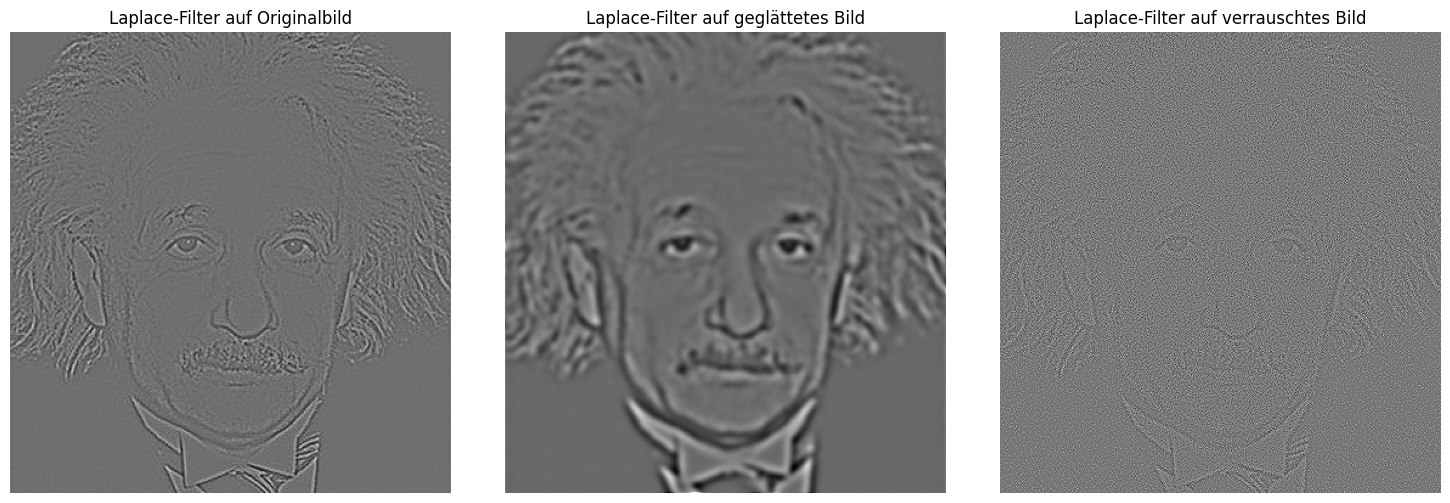

In [5]:
# Laplace-Filter auf alle drei Bilder anwenden
img_laplace_original = laplace(img)
img_laplace_gaussian = laplace(img_gaussian)
img_laplace_noisy = laplace(img_noisy)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_laplace_original, cmap='gray')
axes[0].set_title("Laplace-Filter auf Originalbild")
axes[0].axis('off')

axes[1].imshow(img_laplace_gaussian, cmap='gray')
axes[1].set_title("Laplace-Filter auf geglättetes Bild")
axes[1].axis('off')

axes[2].imshow(img_laplace_noisy, cmap='gray')
axes[2].set_title("Laplace-Filter auf verrauschtes Bild")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Beobachtungen zum Laplace-Filter

**Laplace auf Originalbild:** Der Filter hebt die Kanten deutlich hervor und erzeugt ein klares Kantendetektor-Bild, das die Konturen von Einsteins Gesicht scharf abbildet. 

**Laplace auf geglättetes Bild:** Das weichgezeichnete Bild führt zu weniger detaillierten Kanten.

**Laplace auf verrauschtes Bild:** Das Rauschen wird vom Laplace-Filter als zusätzliche Kanten interpretiert, daher sind die echten Kanten zu schwach dargestellt und andere Stellen sind fälschlicherweise hervorgehoben.

## 1.3

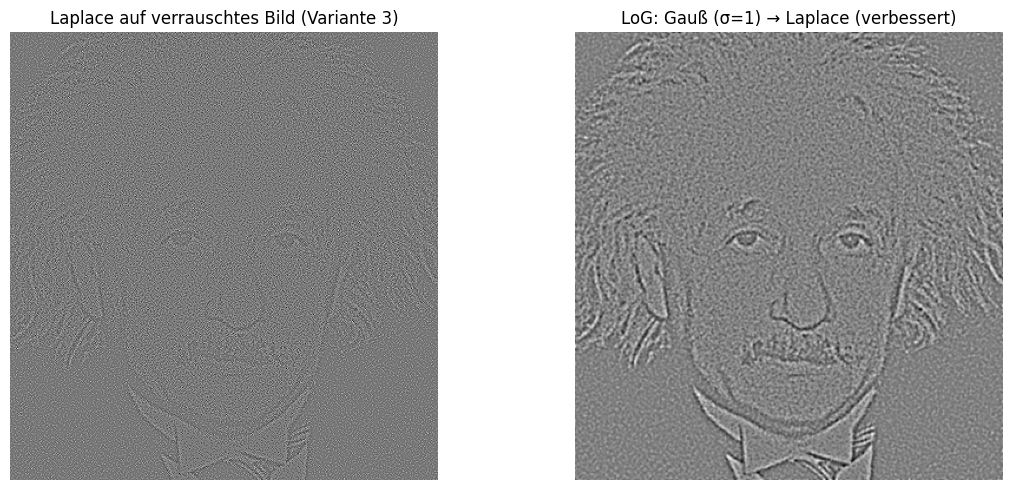

In [16]:
# Verbesserungsvorschlag: Gaußschen Weichzeichner VOR dem Laplace-Filter anwenden (LoG)
# Vor der Kantenextraktion wird das verrauschte Bild mit einem Gaußfilter (σ=1) geglättet,
# um hochfrequentes Rauschen zu dämpfen, bevor Laplace es verstärkt.
img_noisy_smoothed = gaussian(img_noisy, sigma=1)
img_laplace_noisy_improved = laplace(img_noisy_smoothed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_laplace_noisy, cmap='gray')
axes[0].set_title("Laplace auf verrauschtes Bild (Variante 3)")
axes[0].axis('off')

axes[1].imshow(img_laplace_noisy_improved, cmap='gray')
axes[1].set_title("LoG: Gauß (σ=1) → Laplace (verbessert)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Begründung: Gaußglättung vor dem Laplace-Filter (LoG)

**Methode:** Vor der Anwendung des Laplace-Filters wird ein Gaußscher Weichzeichner (σ=1) auf das verrauschte Bild angewendet. Diese Kombination ist als **Laplacian of Gaussian (LoG)** bekannt.

**Begründung der Wahl:** Der Laplace-Filter ist ein Hochpassfilter und verstärkt alle hochfrequenten Signalanteile – sowohl echte Kanten als auch Rauschen. Da Gaußsches Rauschen gerade in hohen Frequenzen stark vertreten ist, wird es durch den Laplace-Filter massiv hervorgehoben (vgl. Variante 3 in 1.2). Der Gaußfilter dämpft gezielt diese hochfrequenten Anteile, bevor Laplace angewendet wird. Er ist dabei die einfachste aus der Vorlesung bekannte Methode zur Rauschunterdrückung.

**Unterschiede:** Im verbesserten LoG-Bild sind die echten Kanten (Augen, Nase, Gesichtskontur) wieder deutlich sichtbar, während der Großteil der Rauschartefakte unterdrückt wurde. Mit wachsendem σ steigt die Rauschunterdrückung weiter, jedoch werden die Kanten zunehmend unschärfer – es gilt also einen geeigneten Kompromiss zu wählen.


## 1.4

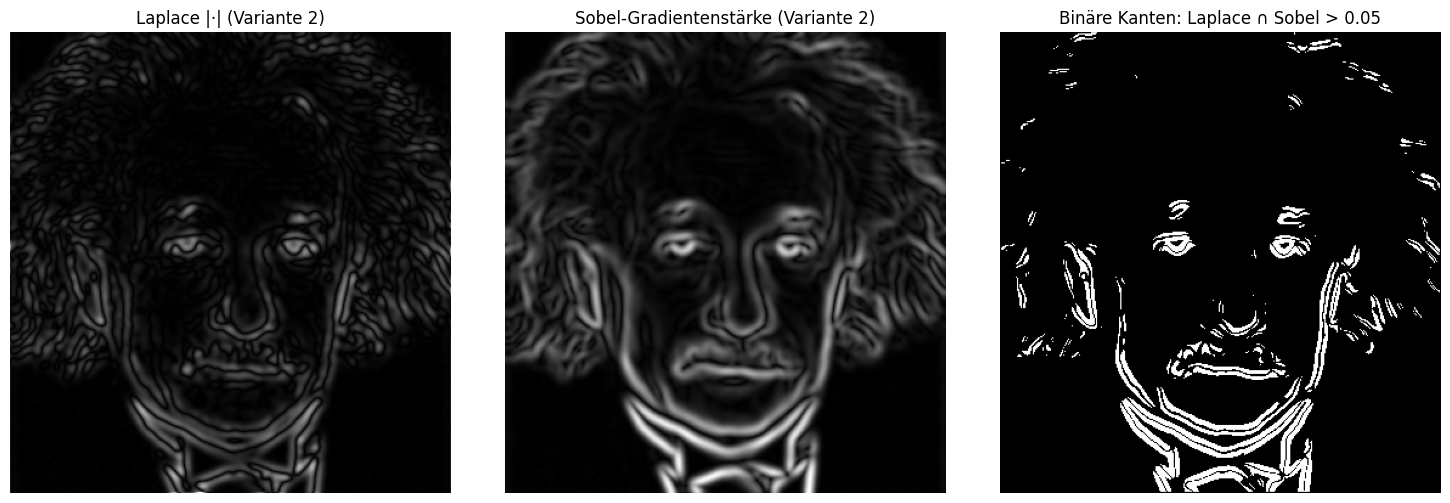

Anteil Kantenpixel: 7.29%


In [17]:
# Sobel-Gradientenstärke auf dem geglätteten Bild (Variante 2) berechnen
img_sobel_gaussian = sobel(img_gaussian)

# Schwellenwert für die Sobel-Gradientenstärke (kann angepasst werden)
threshold = 0.05

# Schritt 1: Kantenkandidaten aus dem Laplace-Ergebnis (Variante 2) – alle Pixel mit |Laplace| > epsilon
laplace_edges = np.abs(img_laplace_gaussian) > 0.005

# Randpixel ignorieren (gemäß Aufgabenhinweis)
laplace_edges[0, :]  = False
laplace_edges[-1, :] = False
laplace_edges[:, 0]  = False
laplace_edges[:, -1] = False

# Schritt 2: Schwache Kanten (geringe Sobel-Gradientenstärke) aussortieren
# Resultat: Kantenpixel = 1, alle anderen = 0
edges_binary = (laplace_edges & (img_sobel_gaussian > threshold)).astype(np.float64)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.abs(img_laplace_gaussian), cmap='gray')
axes[0].set_title("Laplace |·| (Variante 2)")
axes[0].axis('off')

axes[1].imshow(img_sobel_gaussian, cmap='gray')
axes[1].set_title("Sobel-Gradientenstärke (Variante 2)")
axes[1].axis('off')

axes[2].imshow(edges_binary, cmap='gray')
axes[2].set_title(f"Binäre Kanten: Laplace ∩ Sobel > {threshold}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Anteil Kantenpixel: {edges_binary.mean() * 100:.2f}%")


## 1.5


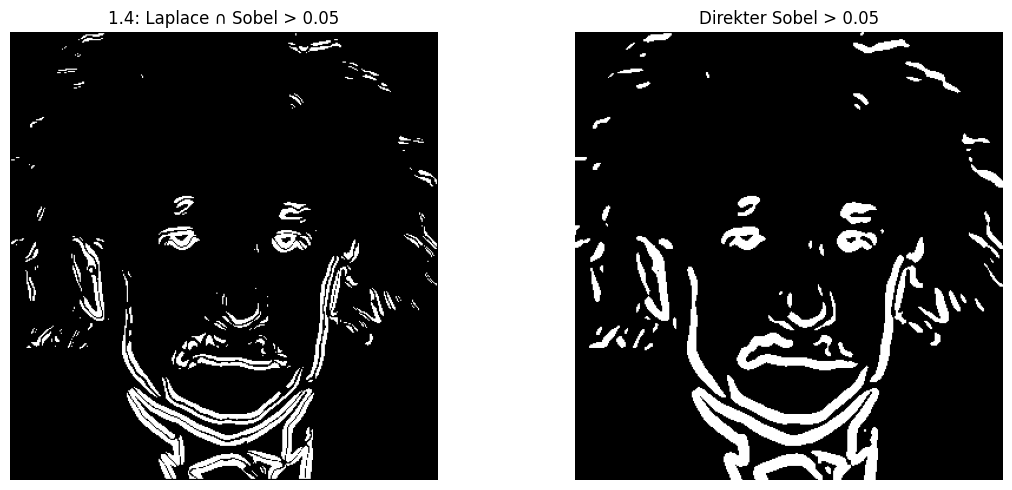

Identische Pixel:        96.67%
Nur in Sobel:            3.33%
Nur in Laplace ∩ Sobel:  0.00%


In [18]:
# Direkter Sobel-Filter auf Variante 2 – binärisiert mit gleichem Schwellenwert
edges_sobel_only = (img_sobel_gaussian > threshold).astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(edges_binary, cmap='gray')
axes[0].set_title(f"1.4: Laplace ∩ Sobel > {threshold}")
axes[0].axis('off')

axes[1].imshow(edges_sobel_only, cmap='gray')
axes[1].set_title(f"Direkter Sobel > {threshold}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

diff = np.abs(edges_binary - edges_sobel_only)
print(f"Identische Pixel:        {(diff == 0).mean() * 100:.2f}%")
print(f"Nur in Sobel:            {((edges_sobel_only == 1) & (edges_binary == 0)).mean() * 100:.2f}%")
print(f"Nur in Laplace ∩ Sobel:  {((edges_binary == 1) & (edges_sobel_only == 0)).mean() * 100:.2f}%")


### Vergleich: Laplace ∩ Sobel vs. direkter Sobel

**Direkter Sobel-Filter:** Jeder Pixel mit einer Gradientenstärke oberhalb des Schwellenwerts wird als Kante markiert. Da der Sobel-Filter auf die Stärke des Gradienten reagiert, entstehen breite, ausgefranste Kantenbereiche – in Regionen mit sanftem Übergang werden viele benachbarte Pixel gemeinsam als Kante erkannt.

**Laplace ∩ Sobel (Variante 1.4):** Das Laplace-Ergebnis reagiert auf Krümmungsänderungen der Intensität und hat an den eigentlichen Kantenpositionen (Nulldurchgängen) hohe Absolutwerte. Durch die zusätzliche Sobel-Bedingung werden nur Pixel behalten, die sowohl im Laplace-Bild als Kante erkannt werden als auch eine hohe Gradientenstärke nach Sobel aufweisen. Das Ergebnis ist deutlich **dünner und präziser lokalisiert** – weniger überflüssige Kantenpixel in Bereichen mit nur schwachem Gradienten. Gleichzeitig entfallen Pixel, die Sobel als Kante wertet, die aber im Laplace-Bild nicht als Kantenkandidaten erscheinen.
